# LINEAR REGRESSION

In [121]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

In [122]:
df = pd.read_csv("homeprices.csv")
df

,area,bedrooms,age,price
0,2600,3.0,20,550000
1,3000,4.0,15,565000
2,3200,NaN,18,610000
3,3600,3.0,30,595000
4,4000,5.0,8,760000
5,4100,6.0,8,810000


## To just see

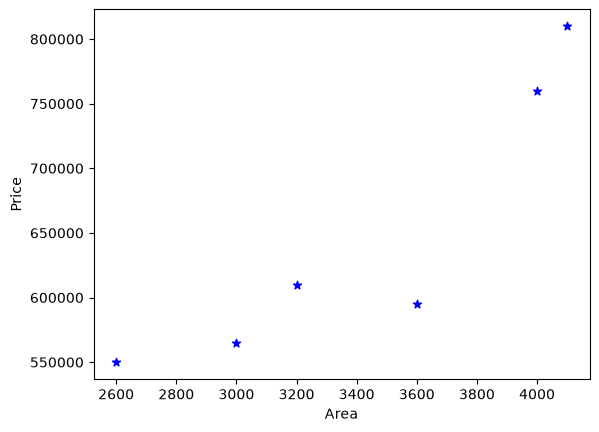

In [123]:
%matplotlib inline
plt.xlabel("Area")
plt.ylabel("Price")
plt.scatter(df.area, df.price, color = "blue", marker = "*")

#### Step 3: Prepare the Data (Features and Target)
**Separate your dataset** into features

The **independent variables** - **area** 

**The target** - want to **predict**, e.g., **price**).

In [124]:
#Note: Scikit-learn expects the feature variable (X) to be a 2D array or DataFrame, which is why we use double brackets [[...]].


# Feature(s) - must be 2D (DataFrame)
X = df[['area']]
X


,area
0,2600
1,3000
2,3200
3,3600
4,4000
5,4100


In [125]:
# Target variable - 1D (Series)
y = df['price']
y

0    550000
1    565000
2    610000
3    595000
4    760000
5    810000
Name: price, dtype: int64

In [126]:
# Create the model
model = LinearRegression()

# Train (fit) the model using your data
model.fit(X, y)   #print("Model trained successfully!")

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[167.31]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['area']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,7.669e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [72]:
# Example: Predict the price for a home with an area of 3300 sq. ft.
new_area = pd.DataFrame([[3300]], columns=['area']) # Using a DataFrame keeps feature names matching
new_area

,area
0,3300


In [73]:
predicted_price = model.predict(new_area)

print(f"Predicted Price: ${predicted_price[0]:,.2f}")

Predicted Price: $628,715.75


#### Generate CSV file with list of home price predictions

In [117]:
area_df = pd.read_csv("areas.csv")
area_df

,area
0,1000
1,1500
2,2300
3,3540
4,4120
5,4560
6,5490
7,3460
8,4750
9,2300


In [118]:
model.predict(area_df).round(2)

array([ 316404.11,  384297.95,  492928.08,  661304.79,  740061.64,
        799808.22,  926090.75,  650441.78,  825607.88,  492928.08,
       1402705.48, 1348390.41, 1144708.9 ])

In [119]:
area_df['prices'] = model.predict(area_df).round(0).astype(int)
area_df

,area,prices
0,1000,316404
1,1500,384298
2,2300,492928
3,3540,661305
4,4120,740062
5,4560,799808
6,5490,926091
7,3460,650442
8,4750,825608
9,2300,492928


In [120]:
area_df.to_csv('prediction.csv', index= False)